# Decision Tree Model on Titanic Dataset

This section explains the libraries used for building and visualizing the model.

## Importing Required Libraries

NumPy and Pandas are used for data handling and preprocessing. DecisionTreeClassifier is used to build the classification model, and Matplotlib with plot_tree helps in visualizing how the decision tree makes decisions.

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

## Loading the Dataset

The Titanic dataset is loaded using Pandas from a CSV file into a DataFrame. The head() function is used to display the first few rows, helping us understand the structure and contents of the data.

In [11]:
df=  pd.read_csv('Titanic.csv')
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Gini Impurity Function

This function calculates the Gini impurity, which measures how mixed the classes are in a dataset. A lower Gini value indicates a purer node, which helps the decision tree choose the best split.

In [12]:
def gini(samples):
    sum_samples = sum(samples)
    score=0
    probas=[]
    for sample in samples:
        proba= sample/sum_samples
        probas.append(proba)
    for proba in probas:
        score += proba*(1-proba)
    return score

## Entropy Function

This function calculates entropy, which measures the level of uncertainty or impurity in the data. Lower entropy indicates more pure data, helping the decision tree make better splitting decisions.

In [13]:
def entropy(samples):
    sum_samples = sum(samples)
    score=0
    probas=[]
    for sample in samples:
        proba= sample/sum_samples
        probas.append(proba)
    for proba in probas:
        score += proba*np.log(proba)
    return -1*score

## Calculating Entropy for Sample Data

Here, entropy is calculated for a sample distribution of classes. This helps demonstrate how impurity is measured based on the proportion of different classes in the dataset.

In [14]:
samples= [100,25,0]
entropy(samples)

C:\Users\mohit\AppData\Local\Temp\ipykernel_12784\104340150.py:9: RuntimeWarning: divide by zero encountered in log
  score += proba*np.log(proba)
C:\Users\mohit\AppData\Local\Temp\ipykernel_12784\104340150.py:9: RuntimeWarning: invalid value encountered in scalar multiply
  score += proba*np.log(proba)


np.float64(nan)

## Encoding Categorical Data

The 'Sex' column is converted from categorical values (male, female) into numerical form using mapping. This is required because machine learning models can only work with numerical data.

In [15]:
sex_mapping= {
    'female':0,
    'male':1
}
df.Sex= df.Sex.map(sex_mapping)

## Feature Selection and Model Initialization

The number of unique values in the 'Pclass' column is checked to understand its categories. Then, relevant features ('Sex' and 'Pclass') are selected for training, and a Decision Tree model is initialized.

In [16]:
df.Pclass.nunique()
features= ['Sex','Pclass']
model= DecisionTreeClassifier()

## Model Training

The Decision Tree model is trained using the selected features as input and the 'Survived' column as the target variable. This allows the model to learn patterns and relationships in the data for prediction.

In [17]:
model.fit(df[features],df.Survived)

DecisionTreeClassifier()

## Visualizing the Decision Tree

The trained decision tree is visualized using Matplotlib and plot_tree. This helps in understanding how the model makes decisions based on the selected features.

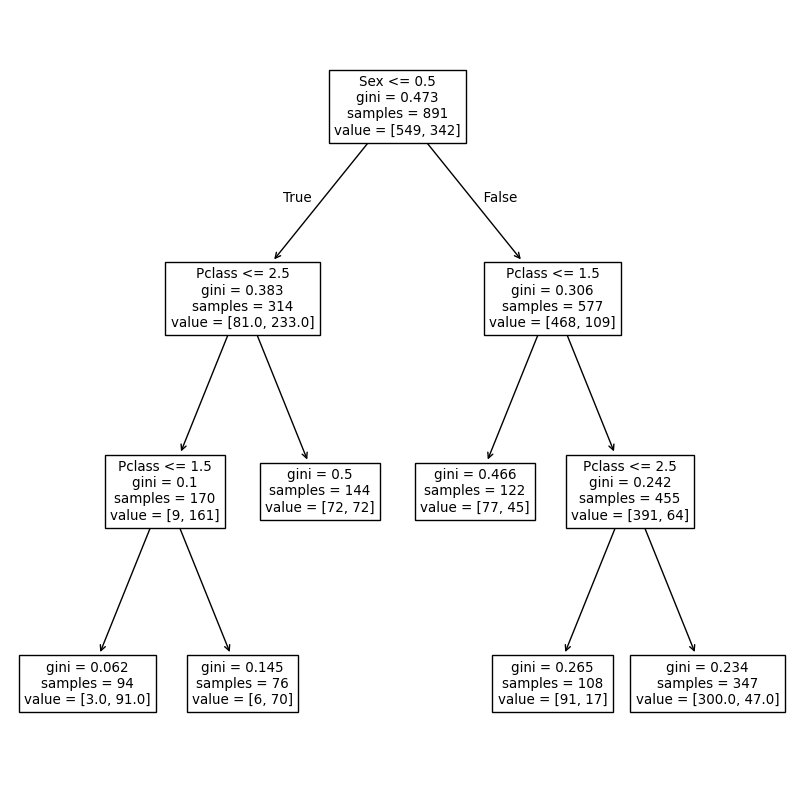

In [18]:
plt.figure(figsize= (10,10))
plot_tree(model,feature_names=features)
plt.show()

## Model Evaluation

The trained model is used to make predictions on the dataset, and accuracy is calculated by comparing predicted values with actual values. The result is displayed in both decimal and percentage form to measure the model's performance.

In [19]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(df[features])
accuracy = accuracy_score(df.Survived, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.7867564534231201
Accuracy (%): 78.67564534231201
